In [25]:
import qiskit
import phoenix
import json
from qiskit.quantum_info import Operator

**Load Pauli strings and coefficients from a JSON file and construct a `Hamiltonian` instance**

In [30]:
with open("../benchmarks/uccsd_json/NH_frz_JW_sto3g.json", "r") as f:
    data = json.load(f)

M = 20
data["paulis"] = data["paulis"][:M]
data["coeffs"] = data["coeffs"][:M]
ham = phoenix.Hamiltonian(data["paulis"], data["coeffs"])
# ham = phoenix.Hamiltonian(['XXXZIYZI', 'YXXZIYYI', 'ZXXZIYZI'], [-0.0125, -0.0125, -0.0125])
u = ham.unitary_evolution()

In [31]:
ham.print_tableau()  # BSF representation of the Pauli terms in the Hamiltonian

+------------------------------------------------------------+
|                   Display index: q0...q9                   |
+------------+---------------------+---------------------+---+
|   Pauli    |        X part       |        Z part       | s |
+------------+---------------------+---------------------+---+
| IIIIIIYZZX | 0 0 0 0 0 0 1 0 0 1 | 0 0 0 0 0 0 1 1 1 0 | 0 |
| IYZZXIIIII | 0 1 0 0 1 0 0 0 0 0 | 0 1 1 1 0 0 0 0 0 0 | 0 |
| IIIIIIXZZY | 0 0 0 0 0 0 1 0 0 1 | 0 0 0 0 0 0 0 1 1 1 | 0 |
| IXZZYIIIII | 0 1 0 0 1 0 0 0 0 0 | 0 0 1 1 1 0 0 0 0 0 | 0 |
| IIIIIYZZZX | 0 0 0 0 0 1 0 0 0 1 | 0 0 0 0 0 1 1 1 1 0 | 0 |
| YZZZXIIIII | 1 0 0 0 1 0 0 0 0 0 | 1 1 1 1 0 0 0 0 0 0 | 0 |
| IIIIIXZZZY | 0 0 0 0 0 1 0 0 0 1 | 0 0 0 0 0 0 1 1 1 1 | 0 |
| XZZZYIIIII | 1 0 0 0 1 0 0 0 0 0 | 0 1 1 1 1 0 0 0 0 0 | 0 |
| IIIIIIYZXI | 0 0 0 0 0 0 1 0 1 0 | 0 0 0 0 0 0 1 1 0 0 | 0 |
| IYZXIIIIII | 0 1 0 1 0 0 0 0 0 0 | 0 1 1 0 0 0 0 0 0 0 | 0 |
| IIIIIIXZYI | 0 0 0 0 0 0 1 0 1 0 | 0 0 0 0 0 0 0 1 1 

In [32]:
qc_trivial = ham.generate_circuit()
phoenix.utils.print_circ_info(qc_trivial, title="Trivial synthesized circuit")
print(qc_trivial.count_ops())
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_trivial).to_matrix()))

+----------------------------------------------------------+
|               Trivial synthesized circuit                |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |    204    |     104      |   80  |    52    |
+------------+-----------+--------------+-------+----------+
OrderedDict({'cx': 104, 'h': 40, 'sx': 20, 'rz': 20, 'sxdg': 20})


In [33]:
qc_phoenix = phoenix.compile_hamiltonian_simulation(ham)
phoenix.utils.print_circ_info(qc_phoenix, title="PHOENIX synthesized circuit")
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_phoenix).to_matrix()))
print(qc_phoenix.count_ops())

+----------------------------------------------------------+
|               PHOENIX synthesized circuit                |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |    148    |      46      |   41  |    20    |
+------------+-----------+--------------+-------+----------+
OrderedDict({'u': 102, 'cx': 46})


In [34]:
qc_phoenix.count_ops().get("cx", 0)

46

In [35]:
qc_phoenix.draw(fold=-1)

global phase: 4.2226
          ┌────────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             ┌─────────────────────┐                            ┌──────────────────────┐                             ┌─────────────────┐                ┌───────────────┐               ┌───────────────────┐             ┌───────────────────┐               ┌───────────────┐             ┌─────────────────────┐        ┌─────────────────────┐     ┌─────────────────────┐                            
q_0: ─────┤ U(0,-π,-π) ├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■───────────────┤ U(0,2.9069,0.23467) ├─────────────■──────────────┤ U(0,0.86718,0.45838) ├───────────■─────────────────┤ U(0.1,-π/2,π/2) ├────────■───────┤ U(0.1,-π,π/2) ├───────■───────┤ U(π/2,-π/2,1.816) ├───────■─────┤ U(3.0416,-π,-π/2) ├──────■────────┤ U(π/2,-π/2,0) ├────────■────┤ U(0,-1.0919,1.0919) ├─────■──┤ U(0,-1.0919,1.0919) ├──■──┤ U(0,-1.0517,1.0517) ├────────────────────────────
     ┌────┴────────────┴───┐         ┌───────────────────┐                               ┌────────────────────┐                                                                                       ┌───────────────────┐                                      ┌───────────────┐                                                                                     ┌─────────────────┐                                      ┌───────────────────┐                ┌───────────────┐                             ┌──────────────────┐            ┌─┴─┐             ├─────────────────────┤             │              └──────────────────────┘           │                 └─────────────────┘        │       └───────────────┘       │       └───────────────────┘       │     └───────────────────┘      │        └───────────────┘        │    └─────────────────────┘     │  └─────────────────────┘┌─┴─┐└┬────────────────────┤                            
q_1: ┤ U(π/2,-π/2,-2.4251) ├───■─────┤ U(3.0416,-π,-π/2) ├───────────────■───────────────┤ U(0.85425,-π,-π/2) ├─────────────────────────────────────────────────────────────────────■─────────────────┤ U(3.0416,-π,-π/2) ├──────────────────■───────────────────┤ U(π/2,-π/2,0) ├──────────────────────────────────────────────────────────────────────■──────────────┤ U(π/2,-π/2,π/2) ├──────────────────────────────■───────┤ U(3.0416,-π,-π/2) ├───────■────────┤ U(π/2,-π/2,0) ├─────────────────■───────────┤ U(π/2,-π,1.7002) ├────────────┤ X ├─────────────┤ U(2.0747,-π/2,-π/2) ├─────────────┼─────────────────────────────────────────────────┼────────────────────────────────────────────┼───────────────────────────────┼───────────────────────────────────┼────────────────────────────────┼─────────────────────────────────┼────────────────────────────────┼─────────────────────────┤ X ├─┤ U(π/2,-0.63333,-π) ├────────────────────────────
     ├─────────────────────┴┐┌─┴─┐┌──┴───────────────────┴───┐         ┌─┴─┐          ┌──┴────────────────────┴─┐                             ┌──────────────────────┐              │                 └───────────────────┘                  │                 

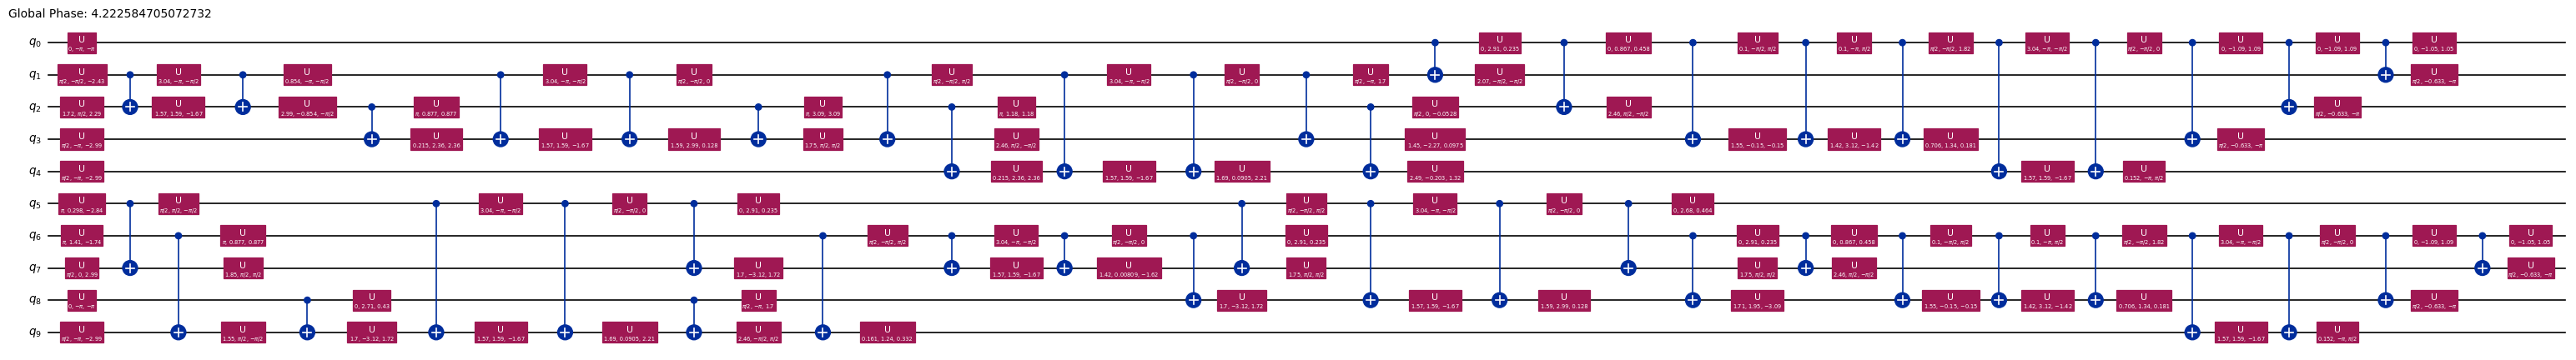

In [36]:
qc_phoenix.draw("mpl", fold=-1, scale=0.6)